# Reconstructing Colleague Networks with Forest Pursuit

In [1]:
import numpy as np
import networkx as nx
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)
sns.set_theme(style='white')

## Problem Setting

Synthesizing a network of colleagues that ask each other to join them on papers:

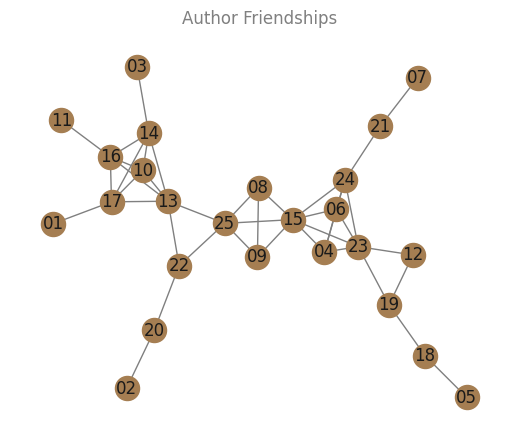

In [2]:
n_authors=25
author_idx = pd.CategoricalIndex((f'author_{i:>02}' for i in range(1,n_authors+1)))

# friends with some cliques
friendships = nx.line_graph(nx.random_labeled_tree(len(author_idx)+1, seed=7)) # real events... what "happens" as evidence of a relationship

G = nx.relabel.relabel_nodes(
    nx.convert_node_labels_to_integers(friendships),
    dict(zip(range(n_authors),author_idx.categories.tolist()))
)  # inferred structure


A = nx.adjacency_matrix(G).todense()
L = nx.laplacian_matrix(G).todense()


def draw_G(G, ax=None):
    
    pos=nx.layout.kamada_kawai_layout(G)
    nx.draw(G, pos=pos, 
            node_color='xkcd:puce', edge_color='grey', ax=ax)
    nx.draw_networkx_labels(G, pos=pos, font_color='k',labels={n:n.split('_')[-1] for n in G}, ax=ax)
    plt.title('Author Friendships', color='grey')
    return pos
f = plt.figure(figsize=(5,4)).patch.set_alpha(0.)
pos = draw_G(G)

Alternatively, we can view this network as an adjacency matrix:

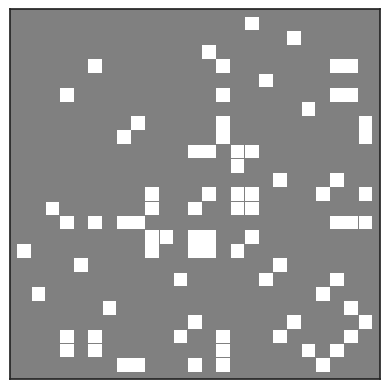

In [3]:
from affinis.plots import hinton
hinton(A)

Now we need to simulate the process of authors joining each list of authors. 

- for 50 papers, we select a random individual to intiate it. 
- for each paper, we spread the paper's concept to colleagues.
  - a geometrically distributed number of requests to join will be successful,
  - Each request comes from an existing author, able to ask any of their connected colleagues to join
- Represent the authors on a given paper each week as "active"

We can visualize these author-paper connections as binary "activation" relationships in a matrix, with one author-per-column, one paper-per-row:

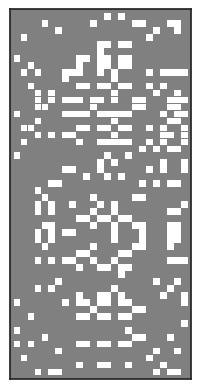

In [4]:
def sim_papers(n_weeks, L, jumps_param=0.1, rng=np.random.default_rng(2)): 
    Arw = ((L/np.diag(L)).pipe(lambda df: np.diag(np.diag(df))-df)*0.5)
    def sim_week(): 
        n_jumps = rng.geometric(jumps_param)
        first = rng.multinomial(1,starting:=np.ones(n_authors)/n_authors) 
        # second = (rng.random()>0.5)*rng.multinomial(1,starting)  # maybe
        infected = first #| second
        for jump in range(n_jumps):
            # print((Arw@infected>1).sum(), infected)
            infected = infected | rng.binomial(1, Arw@(infected/infected.sum()))
        return infected


    yield from (sim_week() for i in range(n_weeks))

# n_obs ~ neg_binom(2, 1/n_nodes)
# n_jumps ~ geom(2/n_nodes)
X = np.vstack(list(sim_papers(
    52, 
    pd.DataFrame(L, columns=author_idx, index=author_idx), 
    0.05,
    #  rng=rng
)))
Xdf = pd.DataFrame(X, columns=author_idx)

# Xstack = np.vstack([X, -X])#.mean(axis=0)

hinton(X)
# plt.axis('off');

Number of papers each author participated on:

/home/rtbs/code/thesis/affinis/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

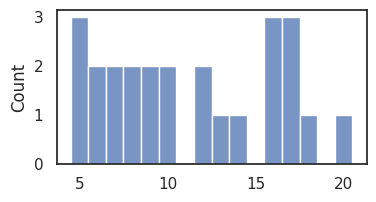

In [5]:
plt.figure(figsize=(4,2))
sns.histplot(Xdf.sum(axis=0), discrete=True)

Number of authors on each paper:

/home/rtbs/code/thesis/affinis/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

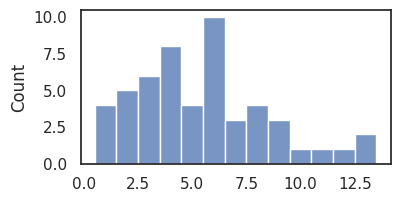

In [6]:
plt.figure(figsize=(4,2))
sns.histplot(Xdf.sum(axis=1), discrete=True)

## Association functions

The core of the `affinis` library lives within the `affinis.associations` module.

<Axes: >

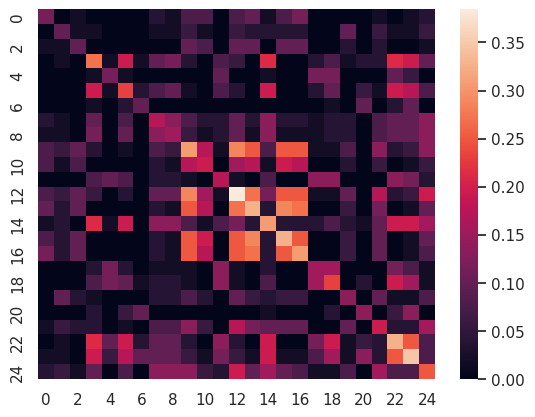

In [7]:
import affinis.associations as aff 
# import coocur_prob, ochiai
# from affinis.plots import hinton 


cooc = aff.coocur_prob(X, pseudocts=0.)

csim = aff.ochiai(X, pseudocts=0.)

sns.heatmap(cooc)
# hinton(L)

<Axes: >

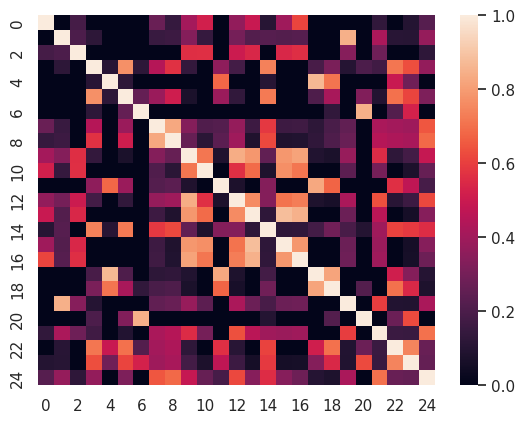

In [8]:
# hinton(csim)
sns.heatmap(csim)
# plt.spy(L, marker='.', color='r')

In [9]:
# from affinis.associations import (
#     coocur_prob,
#     odds_ratio,
#     mutual_information,
#     chow_liu,
#     yule_q, yule_y,
#     ochiai,
#     resource_project,
#     high_salience_skeleton
# )

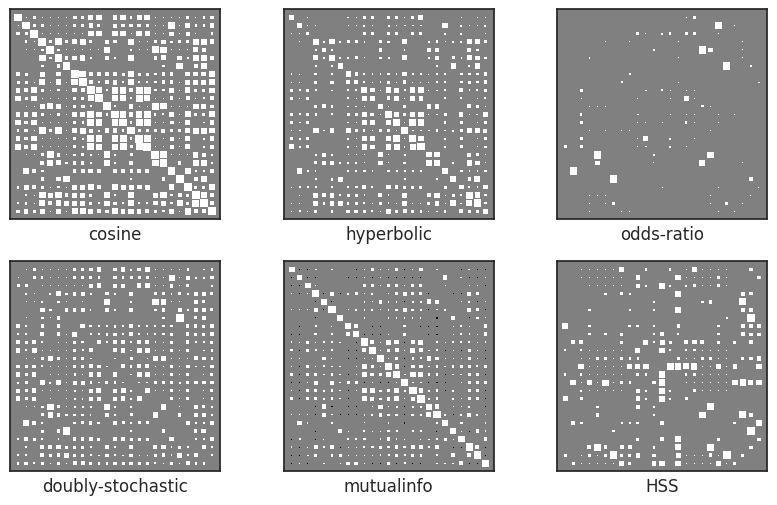

In [34]:
# def prox_to_laplacian(K):
#     A = -_sq(_sq(K))
#     np.fill_diagonal(A,-A.sum(axis=0))
#     return A

psct ='min-connect'
# psct=0

baselines = {
    'cosine': aff.ochiai(X, pseudocts=psct),
    'hyperbolic': aff.hyperbolic_project(X),
    'odds-ratio': aff.odds_ratio(X, pseudocts=psct),
    'doubly-stochastic':aff.doubly_stochastic_filter(X, pseudocts=psct),
    'mutualinfo': aff.mutual_information(X, pseudocts=psct),
    'HSS': aff.high_salience_skeleton(X, pseudocts=psct)
}
f,axs = plt.subplots(nrows=2, ncols=3, figsize=(10,6))

for n, (lab, Aest) in enumerate(baselines.items()): 
    ax = axs.flatten()[n]
    # ax.imshow(Aest)
    hinton(Aest, ax=ax)
    ax.set_xlabel(lab)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

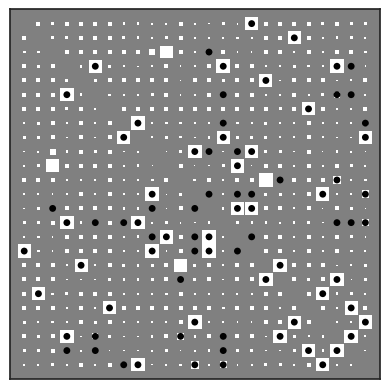

In [35]:
hinton(aff.forest_pursuit(X, pseudocts=psct))
# plt.spy(A, marker='.', color='r')
hinton(-A, marker='.')

In [36]:
from contingency import Contingent
from contingency.plots import PR_contour
from scipy.spatial.distance import squareform
y_true = squareform(A).astype(bool)


m_fp = Contingent.from_scalar(y_true, squareform(forest_pursuit_edge(X, pseudocts=psct)))
m_compare = Contingent.from_scalar(y_true, squareform(baselines['doubly-stochastic']))

(np.float64(0.6281812324194038), np.float64(0.3088492263167929))

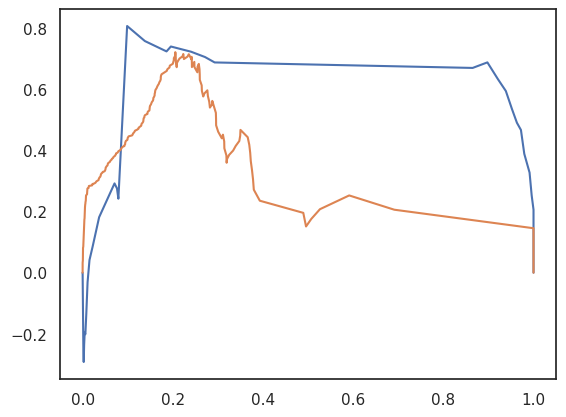

In [37]:
plt.plot(m_fp.weights, m_fp.mcc)
plt.plot(m_compare.weights, m_compare.mcc)

m_fp.expected('mcc'), m_compare.expected('mcc')

(np.float64(0.7663699367933801), np.float64(0.684449884251866))

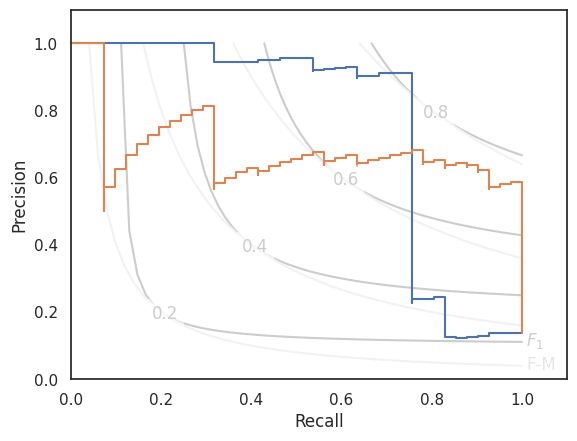

In [38]:
PR_contour()
plt.step(m_fp.recall, m_fp.precision, where='post')
plt.step(m_compare.recall, m_compare.precision, where='post')
m_fp.expected('aps'), m_compare.expected('aps')